In [ ]:
# /// script
# requires-python = ">=3.13"
# dependencies = [
#     "cartopy>=0.25.0",
#     "dynamical-catalog>=0.7.0",
#     "metpy>=1.7.1",
#     "plotly>=6.9.0",
#     "rioxarray>=0.22.0",
# ]
# ///

In [1]:
import dynamical_catalog

ds = dynamical_catalog.open("noaa-hrrr-forecast-48-hour-virtual", chunks=None)

In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rioxarray  # enables the .rio accessor

# create a cartopy CRS for HRRR's native Lambert Conformal grid using the dataset's metadata
crs = ds.spatial_ref.attrs
hrrr_proj = ccrs.LambertConformal(
    central_longitude=crs["longitude_of_central_meridian"],
    central_latitude=crs["latitude_of_projection_origin"],
    standard_parallels=crs["standard_parallel"],
    globe=ccrs.Globe(semimajor_axis=crs["semi_major_axis"], semiminor_axis=crs["semi_minor_axis"]),
)

massden = (
    ds["mass_density_8m"]
    .isel(init_time=-1, lead_time=12)
    .rio.clip_box(-100, 40, -80, 55, crs="EPSG:4326")
    .load()
)

In [8]:
massden

<xarray.DataArray 'mass_density_8m' (y: 474, x: 566)> Size: 2MB
array([[3.20000000e-09, 3.20000000e-09, 3.20000000e-09, ...,
        1.60000000e-10, 1.60000000e-10, 1.60000000e-10],
       [3.20000000e-09, 3.20000000e-09, 3.20000000e-09, ...,
        1.60000000e-10, 1.60000000e-10, 1.60000000e-10],
       [3.52000000e-09, 3.36000000e-09, 3.36000000e-09, ...,
        1.60000000e-10, 1.60000000e-10, 1.60000000e-10],
       ...,
       [1.15740547e-25, 1.15740547e-25, 1.15740547e-25, ...,
        7.68000000e-09, 7.52000000e-09, 5.76000000e-09],
       [1.15740547e-25, 1.15740547e-25, 1.15740547e-25, ...,
        4.96000000e-09, 3.36000000e-09, 2.40000000e-09],
       [1.15740547e-25, 1.15740547e-25, 1.15740547e-25, ...,
        2.88000000e-09, 2.40000000e-09, 2.40000000e-09]], shape=(474, 566))
Coordinates:
  * y                         (y) float64 4kB 1.587e+06 1.584e+06 ... 1.677e+05
  * x                         (x) float64 5kB -2.135e+05 ... 1.481e+06
    latitude                  (y, x) float32 1MB 52.58 52.59 ... 38.77 38.76
    longitude                 (y, x) float32 1MB -100.6 -100.5 ... -80.35 -80.31
    expected_forecast_length  timedelta64[us] 8B 2 days
    lead_time                 timedelta64[us] 8B 12:00:00
    init_time                 datetime64[ns] 8B 2026-07-17T06:00:00
    valid_time                datetime64[ns] 8B 2026-07-17T18:00:00
    spatial_ref               int64 8B 0
Attributes:
    long_name:   Mass density
    short_name:  mdens
    units:       kg m-3
    comment:     Near-surface smoke concentration. Source values at init_time...
    step_type:   instant

Text(0.5, 1.0, '')

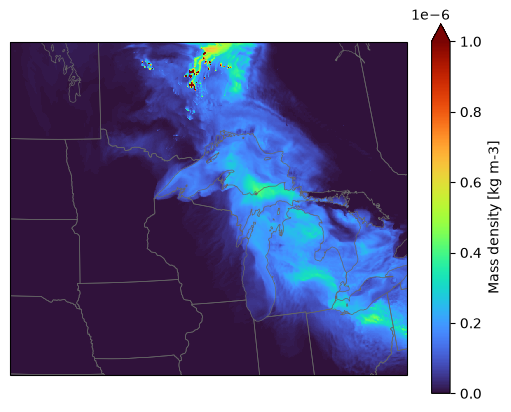

In [9]:
ax = plt.subplot(projection=hrrr_proj)
massden.plot(ax=ax, transform=hrrr_proj, cmap="turbo", vmin=0, vmax=1000e-9)
ax.add_feature(cfeature.STATES, edgecolor="0.4", linewidth=0.5)
ax.set_title("")